# Chapter 9 — Worked Example: SHAP Analysis of the Hennaya Surrogate Model

**AI for Hydrogeologists** — companion notebook

This notebook applies SHAP directly to the multicollinearity trap
discovered in Chapter 8, Exercise 2: raw `feature_importances_` gave the
calibrated K/S/porosity fields almost no credit (combined 0.002) while
elevation-related features dominated (0.839), even though a manual
ablation test proved K/S alone still reach R2=0.944 on the held-out 2012
validation. **Does SHAP give a more informative picture directly, without
needing that extra ablation experiment?**

In [1]:
!pip install shap -q
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import shap
import matplotlib.pyplot as plt
import io

BASE = "https://raw.githubusercontent.com/Dr-LAOUFIAbdessalam/ai-hydrogeologists/main/"


## Rebuild the Chapter 8 surrogate dataset and model

In [2]:
HNOFLO_THRESHOLD = 1e29

def load_all_layers(url):
    import urllib.request
    text = urllib.request.urlopen(url).read().decode("utf-8", errors="ignore")
    lines = text.splitlines()
    layer_idx = [i for i, l in enumerate(lines) if l.startswith("Layer")]
    layer_idx.append(len(lines))
    blocks = {}
    for k in range(len(layer_idx) - 1):
        name = lines[layer_idx[k]].strip()
        chunk = lines[layer_idx[k] + 1:layer_idx[k + 1]]
        df = pd.read_csv(io.StringIO("\n".join(chunk)), sep="\t")
        df = df.loc[:, ~df.columns.str.match("Unnamed")]
        blocks[name] = df
    return blocks["Layer 1"]

MB = BASE + "ch08_physics_informed/data/raw/"
geo = load_all_layers(MB + "geomertry.TXT")
cond = load_all_layers(MB + "Conductivity.TXT")
stor = load_all_layers(MB + "Storage.TXT")
h1981 = load_all_layers(MB + "Simulated_head_1981.TXT")
h2012 = load_all_layers(MB + "Simulated_head_2012.TXT")
h2022 = load_all_layers(MB + "Simulated_head_2022.TXT")

static = geo.merge(cond[["X","Y","Kx","Ky","Kz"]], on=["X","Y"]) \
            .merge(stor[["X","Y","Ss","Sy","PorEff.","PorTot."]], on=["X","Y"])
static = static.rename(columns={"Thick.":"Thick","PorEff.":"PorEff","PorTot.":"PorTot"})

frames = []
for year, hdf in [(1981, h1981), (2012, h2012), (2022, h2022)]:
    df = static.copy()
    df["Head"] = hdf["Head"].values
    df["year"] = year
    df = df[df["Head"] < HNOFLO_THRESHOLD].reset_index(drop=True)
    frames.append(df)
full = pd.concat(frames, ignore_index=True)
for col in ["Kx","Ky","Kz"]:
    full[f"log_{col}"] = np.log10(full[col].clip(lower=1e-12))

feature_cols = ["X","Y","Z","Top","Bot","Thick","log_Kx","log_Ky","log_Kz",
                 "Ss","Sy","PorEff","PorTot","year"]
train = full[full["year"].isin([1981, 2022])].reset_index(drop=True)
test = full[full["year"] == 2012].reset_index(drop=True)
X_train, y_train = train[feature_cols], train["Head"].values
X_test, y_test = test[feature_cols], test["Head"].values

rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)
print(f"Validation R2 (2012, held out): {r2_score(y_test, rf.predict(X_test)):.4f}")


Validation R2 (2012, held out): 0.9657


## SHAP global importance

In [3]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols).sort_values(ascending=False)
print(mean_abs_shap.round(3))

ks_cols = ["log_Kx","log_Ky","log_Kz","Ss","Sy","PorEff","PorTot"]
elev_cols = ["Top","Z","Bot"]
ks_shap = mean_abs_shap[ks_cols].sum(); elev_shap = mean_abs_shap[elev_cols].sum()
total = mean_abs_shap.sum()
print(f"\nSHAP-based K/S/porosity share: {ks_shap/total:.3f} (impurity-based: 0.002)")
print(f"SHAP-based elevation share: {elev_shap/total:.3f} (impurity-based: 0.839)")


Top       22.115
Z         13.679
Y          8.082
Bot        7.447
year       0.841
X          0.812
Thick      0.348
PorTot     0.211
Sy         0.092
PorEff     0.081
Ss         0.080
log_Kx     0.043
log_Ky     0.037
log_Kz     0.000
dtype: float64

SHAP-based K/S/porosity share: 0.010 (impurity-based: 0.002)
SHAP-based elevation share: 0.803 (impurity-based: 0.839)


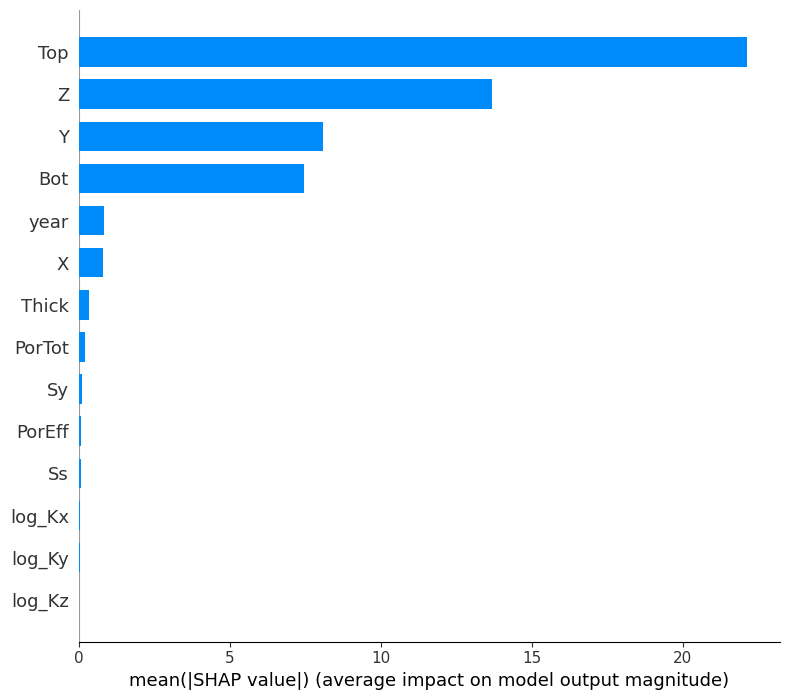

In [4]:
plt.figure(figsize=(8,6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout(); plt.show()


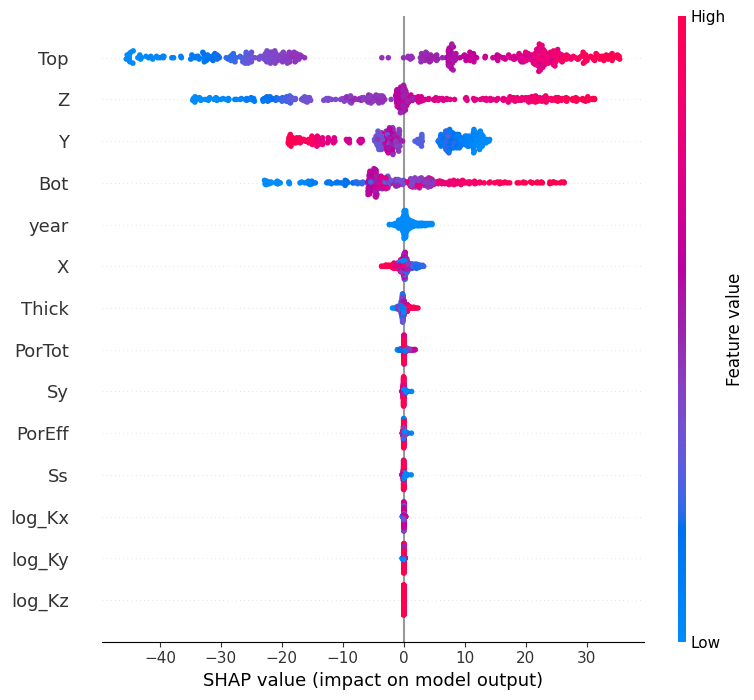

In [5]:
plt.figure(figsize=(8,6))
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout(); plt.show()


## Honest finding: SHAP does NOT resolve this trap either

Contrary to the hypothesis motivating this chapter, **SHAP gives nearly
the same skewed picture as raw impurity importance**: the SHAP-based
K/S/porosity share (~0.01) is almost as small as the impurity-based value
(0.002), and elevation still dominates (~0.80 vs 0.839). TreeSHAP's
attributions are still computed from the same underlying tree splits, so
when two features are highly correlated, SHAP can also fail to fully
disentangle their individual contributions — a documented limitation of
Shapley-value methods under multicollinearity, not unique to
impurity-based importance.

**The manual ablation test from Chapter 8** (refitting with K/S alone,
which reached R2 = 0.944) remains the more reliable diagnostic here.

**Practical lesson for Section 9.6:** SHAP is a substantial improvement
over raw `feature_importances_` for many purposes — it gives signed,
per-observation, theoretically grounded attributions — but it is not a
universal fix for correlated features. Domain-knowledge-driven ablation
experiments remain an essential complementary tool, not a technique SHAP
makes obsolete.

## Local explanation: highest vs. lowest conductivity cells

In [6]:
idx_high_k = X_test["log_Kx"].idxmax()
idx_low_k = X_test["log_Kx"].idxmin()
expected_value = explainer.expected_value
if hasattr(expected_value, "__len__"):
    expected_value = expected_value[0]

for label, idx in [("Highest-conductivity cell", idx_high_k), ("Lowest-conductivity cell", idx_low_k)]:
    print(f"\n--- {label} (row {idx}) ---")
    row_shap = pd.Series(shap_values[idx], index=feature_cols).sort_values(key=abs, ascending=False)
    pred = rf.predict(X_test.iloc[[idx]])[0]
    print(f"Predicted head: {pred:.1f} m (actual: {y_test[idx]:.1f} m, base value: {expected_value:.1f} m)")
    print("Top SHAP contributions:")
    print(row_shap.head(5).round(2))



--- Highest-conductivity cell (row 155) ---
Predicted head: 313.0 m (actual: 324.6 m, base value: 328.5 m)
Top SHAP contributions:
Top    -17.20
Bot      4.43
Z       -3.51
year     1.08
Y       -0.85
dtype: float64

--- Lowest-conductivity cell (row 93) ---
Predicted head: 292.0 m (actual: 292.6 m, base value: 328.5 m)
Top SHAP contributions:
Top   -22.70
Z     -12.67
Y      -2.66
Bot     1.13
X       0.29
dtype: float64


Even for the cell with the highest calibrated conductivity in the
validation set, the individual SHAP explanation is still dominated by
`Top` (elevation) rather than `log_Kx` — consistent with the global
finding above, and a concrete illustration of why local explanations
should be read alongside a broader understanding of feature correlation
in the underlying data, not taken at face value in isolation.